<a href="https://colab.research.google.com/github/JohnMaleek/ML/blob/main/Assignment_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Homeworks**
Exercise 1
Create a plot which shows the inertia values for k = 1,2,3,...,20 of the Kmeans method used in the quantization example. (1p)


k = 1 - Inertia: 6357513937.95
k = 2 - Inertia: 309025471.24
k = 3 - Inertia: 152697034.32
k = 4 - Inertia: 93096359.41
k = 5 - Inertia: 74201154.58
k = 6 - Inertia: 54984153.18
k = 7 - Inertia: 43059755.79
k = 8 - Inertia: 37827858.08
k = 9 - Inertia: 28655472.31
k = 10 - Inertia: 24201049.39
k = 11 - Inertia: 20247822.78
k = 12 - Inertia: 17936415.38
k = 13 - Inertia: 16149538.88
k = 14 - Inertia: 14657677.37
k = 15 - Inertia: 13625352.98
k = 16 - Inertia: 12591792.82
k = 17 - Inertia: 11529351.72
k = 18 - Inertia: 10877500.81
k = 19 - Inertia: 10426149.75
k = 20 - Inertia: 9903702.15


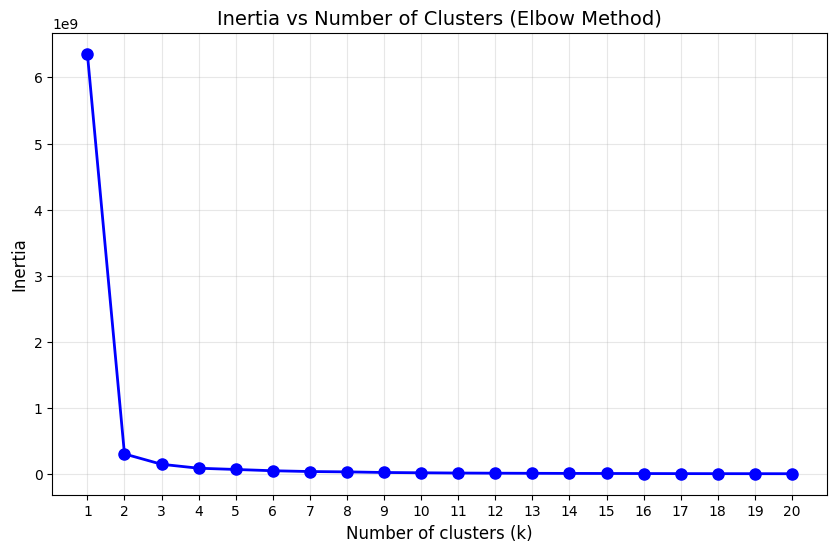

In [4]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.datasets import make_blobs
import numpy as np
import cv2
import warnings
warnings.filterwarnings('ignore')

img_path = "/content/sample_data/deadpool.png"
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

pixels = image.reshape((image.shape[0] * image.shape[1], 3))

# Calculate inertia for k = 1 to 20
k_range = range(1, 21)
inertias = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(pixels)
    inertias.append(model.inertia_)
    print("k = {} - Inertia: {:.2f}".format(k, model.inertia_))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Inertia vs Number of Clusters (Elbow Method)', fontsize=14)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

**Exercise** 2
Following the elbow method, use the k value from the elbow point and generate a compressed version of the Deadpool image using k colours. Visualize the compressed and original images side-by-side similarly as in the last sample code.(1p)

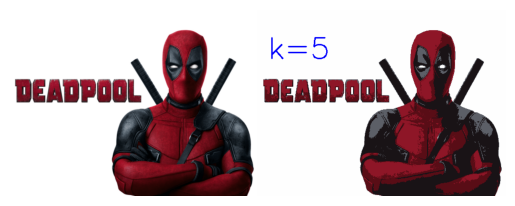


Optimal number of clusters (from elbow method): 5


In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.datasets import make_blobs
import numpy as np
import cv2
import warnings
warnings.filterwarnings('ignore')


img_path = "/content/sample_data/deadpool.png"
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


optimal_k = 5

# Apply k-means
model = MiniBatchKMeans(n_clusters=optimal_k, random_state=42)
labels = model.fit_predict(pixels)


(h, w) = image.shape[:2]
quant_pixels = np.zeros((len(labels), 3), dtype=np.uint8)

for i in range(len(labels)):
    quant_pixels[i] = model.cluster_centers_[labels[i]].astype("uint8")


# Merge the original and quantized images horizontally
quant_image = quant_pixels.reshape((h, w, 3))
cv2.putText(quant_image, "k={}".format(optimal_k), (20, 100), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 2)
out_image = np.hstack([image, quant_image])


plt.figure()
plt.axis("off")
plt.imshow(out_image)
plt.show()

print("\nOptimal number of clusters (from elbow method):", optimal_k)